In [56]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import netCDF4 as nc
import xarray as xr
import wrf

import matplotlib.pyplot as plt
import seaborn as sns

import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.feature as cfeature

sns.set_style('whitegrid')

# About
__Date:__ 02/21/25  
__Author:__ Pat McCornack  
__Purpose:__ Extracts albedo and cloud fraction from given points in order to compare them and develop a cloud/no cloud threshold for cloud fraction. This is in support of comparing the GOES CLC data with WRF model outputs. 

# Functions

In [2]:
def format_ds(wrf_ds):
    lat = wrf_ds['XLAT'].values[:,0]
    lon = wrf_ds['XLONG'].values[0,:]
    time = wrf_ds['Time'].values
    values = wrf_ds.values

    ds = xr.DataArray(
        data=values,
        dims=['time', 'lat', 'lon'],
        coords = {'time' : time, 'lat' : lat, 'lon' : lon}
    )

    return ds

# Read In and Process Data

In [4]:
# Define filepaths
root_dir = Path().resolve().parents[0]
sample_points_fpath = root_dir / 'data/geospatial/clc-cldfrc-sample-points/clc-cldfrc-sample-points.csv'
wrf_fpath = root_dir / 'data/geospatial/wrf-vertical-profile/wrfout-2008-08-vertprofile.nc'
clc_fpath = root_dir / 'data/geospatial/clemesha-clc/cldalb-sci.nc'
wrf_da_fpath = '/Users/patmccornack/Documents/ucsb_fog_project/_repositories/sci-wrf-analysis/data/wrf_low_cloud/wrf-low-clouds-temp.nc'

# Read in data
clc_da = xr.open_dataarray(clc_fpath)
wrf_da = xr.open_dataarray(wrf_da_fpath)
sample_points = pd.read_csv(sample_points_fpath, usecols=['Station', 'Latitude', 'Longitude', 'type'], )
sample_points.loc[sample_points['Station'].isna(), 'Station'] = [f"point_{i+1}" for i in range(sample_points['Station'].isna().sum())]
sample_points = sample_points.dropna()


In [ ]:
# Define cloud thresholds
low_cloud=30
mid_cloud=2000
high_cloud=5000

# Extract cloud fractions and subset to low clouds
wrf_nc = nc.Dataset(wrf_fpath)
cld_frac = wrf.g_cloudfrac.get_cloudfrac(wrf_nc,timeidx=wrf.ALL_TIMES,vert_type='height_agl',
                                          low_thresh=low_cloud,
                                          mid_thresh=mid_cloud,
                                          high_thresh=high_cloud) # this is all three layers, we subselect later
cld_frac = cld_frac.sel(low_mid_high='low')

In [ ]:
# Convert wrf UTC to PDT
#wrf_da = format_ds(cld_frac)
#wrf_da['time'] = wrf_da['time'] - pd.to_timedelta(7, unit='h')  # Convert from UTC to PDT


In [5]:
clc_da['time'] = pd.to_datetime(clc_da['time'].values).ceil('30min')
clc_da

<xarray.DataArray 'cldalb' (time: 88908, lat: 41, lon: 51)> Size: 744MB
[185906628 values with dtype=float32]
Coordinates:
  * lon      (lon) float64 408B -120.0 -120.0 -120.0 ... -119.5 -119.5 -119.5
  * lat      (lat) float64 328B 33.8 33.81 33.82 33.83 ... 34.18 34.19 34.2
  * time     (time) datetime64[ns] 711kB 1996-05-01T07:00:00 ... 2019-09-30T1...
Attributes:
    units:      %
    long_name:  cloud albedo

In [6]:
times = clc_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
print(times.dt.hour.unique())

times = wrf_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
print(times.dt.hour.unique())

[ 7  8  9 10 11 12 13 14 15 16 17 18 19]
[17 18 19 20 21 22 23  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


In [7]:
# Subset both datasets to same frame
lonmin = -119.5049
lonmax = -119.9401
latmin = 33.9487
latmax = 34.1

wrf_da = wrf_da.sel(lat=slice(latmin, latmax), lon=slice(lonmax, lonmin))
clc_da = clc_da.sel(lat=slice(latmin, latmax), lon=slice(lonmax, lonmin))

In [ ]:
# Compare maps of albedo and cloud fraction
time = '1996-06-15T9:00:00.000000000'

fig, ax = plt.subplots(2,1, figsize=(12,12))
wrf_da.sel(time=time).plot(ax=ax[0])
clc_da.sel(time=time).plot(ax=ax[1])


In [14]:
# Subset each to common times
common_times = clc_da['time'].values[np.isin(clc_da['time'], wrf_da['time'])]

clc_da = clc_da.sel(time=common_times)
wrf_da = wrf_da.sel(time=common_times)

times = wrf_da['time'].to_dataframe().reset_index(drop=True)
times = pd.to_datetime(times['time'])
times.dt.hour.unique()


array([17, 18, 19,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16], dtype=int32)

In [16]:
# Align the albedo dataset with wrf dataset
clc_da = clc_da.reindex_like(wrf_da, method='nearest')
ds = xr.Dataset({'albedo' : clc_da, 'low_cloud_frac' : wrf_da})

In [35]:
# Extract values for set of points
df = pd.DataFrame()
for i, row in sample_points.iterrows():
    lat = row['Latitude']
    lon = row['Longitude']
    type = row['type']

    site_ds = ds.sel(lat=lat, lon=lon, method='nearest')
    site_df = site_ds.to_dataframe()[['albedo', 'low_cloud_frac']].reset_index()
    site_df['type'] = row['type']
    site_df['station'] = row['Station'] 

    df = pd.concat([df, site_df], axis=0)

df['time'] = pd.to_datetime(df['time'])
df = df.reset_index(drop=True)
df.head()

,time,albedo,low_cloud_frac,type,station
0,1996-06-21 17:00:00,2.940000,0.471992,land,CAir
1,1996-06-21 18:00:00,1.720000,0.477940,land,CAir
2,1996-06-21 19:00:00,5.690000,0.509640,land,CAir
3,1996-06-22 07:00:00,21.980000,1.000000,land,CAir
4,1996-06-22 08:00:00,20.790001,0.853002,land,CAir


# Compare Albedo with Low Cloud Fraction

In [36]:
df['clc-binary'] = df['albedo'].apply(lambda x : 1 if x > 8.5 else 0)

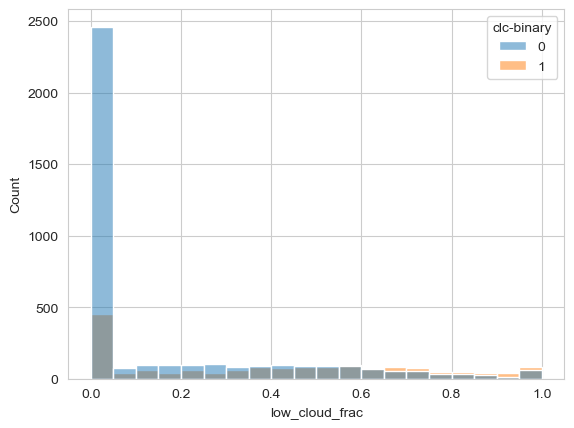

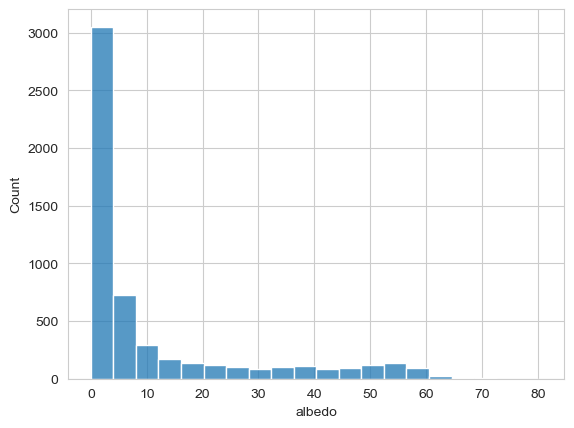

In [39]:
fig, ax = plt.subplots()
sns.histplot(df, x='low_cloud_frac', bins=20, hue='clc-binary')
plt.show()

fig, ax = plt.subplots()
sns.histplot(df, x='albedo', bins=20)
plt.show()

<Axes: xlabel='albedo', ylabel='low_cloud_frac'>

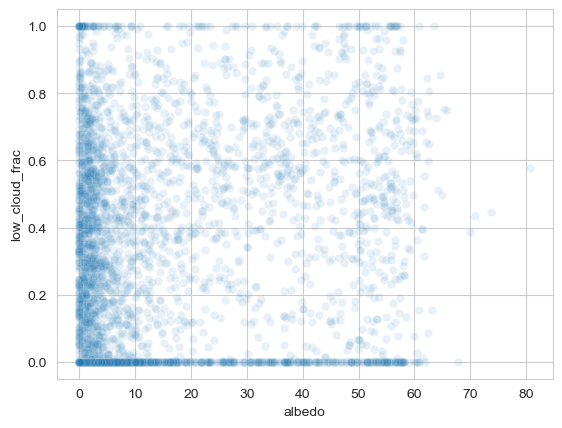

In [40]:
fig, ax = plt.subplots()
sns.scatterplot(data=df,
                x='albedo',
                y='low_cloud_frac',
                alpha=0.1)

In [41]:
# Assume df is your DataFrame with 'albedo' and 'low_cloud_fraction' columns
correlation = df['albedo'].corr(df['low_cloud_frac'])

print(f'Correlation: {correlation}')

Correlation: 0.3439265651305588


# Compare maps 

In [48]:
ds['alb_binary'] = xr.where(ds['albedo'] > 8.5, 1, 0)
ds['wrf_binary'] = xr.where(ds['low_cloud_frac'] > 0.5, 1, 0)
ds['match'] = xr.where((ds['alb_binary'] == ds['wrf_binary']), 1, 0)

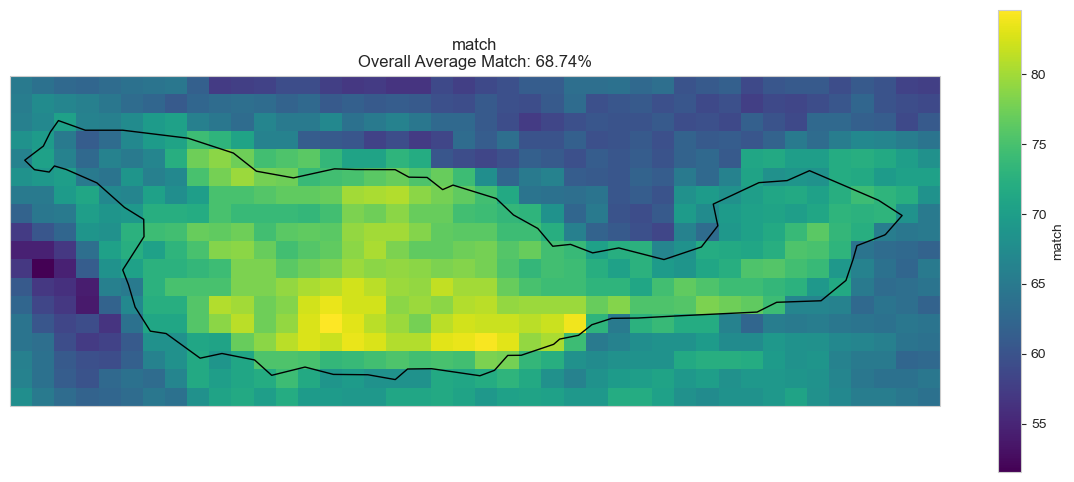

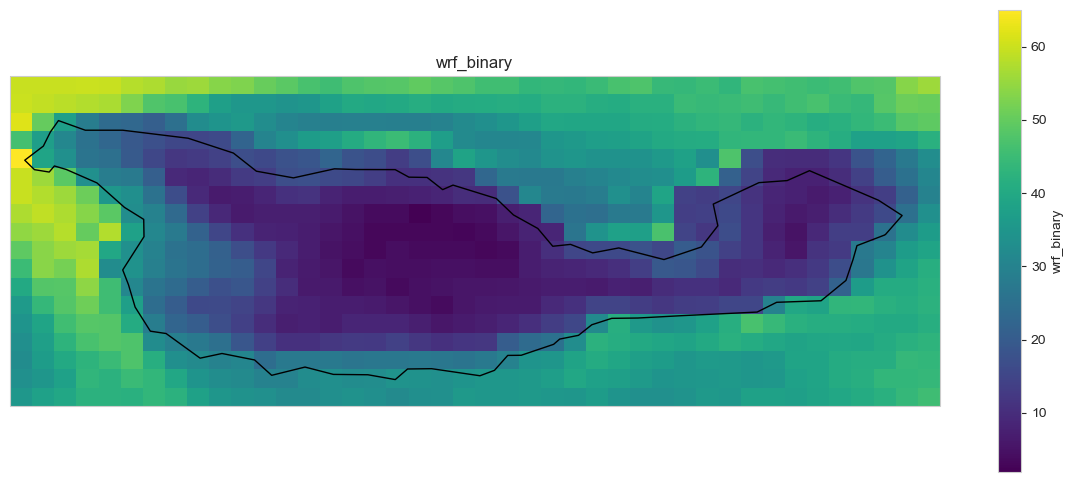

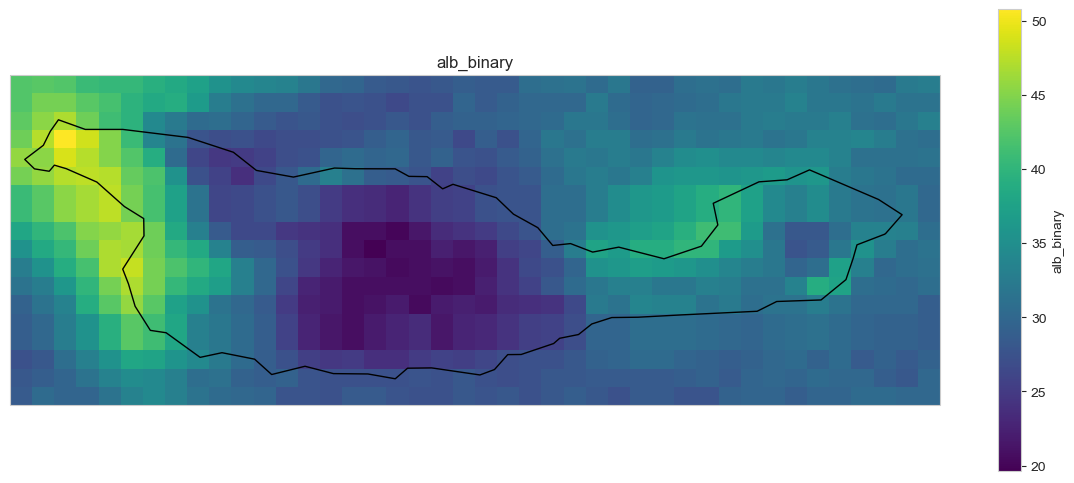

In [103]:
# Get overall match
def plot_overall(ds, var, calc_perc=False):
    overall_ds = ds.sum(dim="time") / ds['time'].shape[0] * 100
    perc_match = float(ds[var].sum() / ds[var].count()) * 100

    fig, ax = plt.subplots(figsize=(15, 12), subplot_kw={'projection': ccrs.PlateCarree()})
    overall_ds[var].plot(ax=ax, cbar_kwargs={"shrink": 0.5})
    if calc_perc:
        ax.set(title=f"{var}\nOverall Average Match: {round(perc_match, 2)}%")
    else:
        ax.set(title=var)
    ax.coastlines()
    plt.show()

plot_overall(ds, 'match', calc_perc=True)
plot_overall(ds, 'wrf_binary')
plot_overall(ds, 'alb_binary')


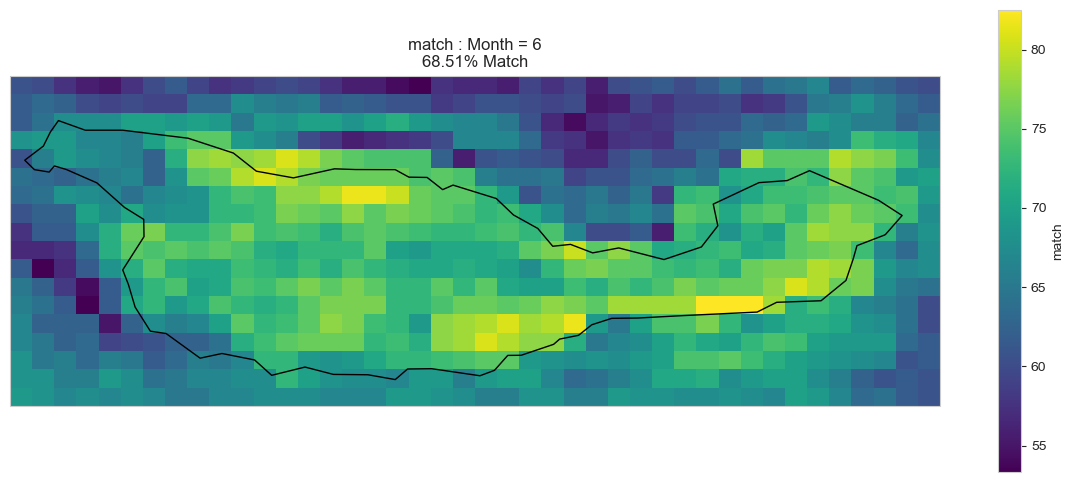

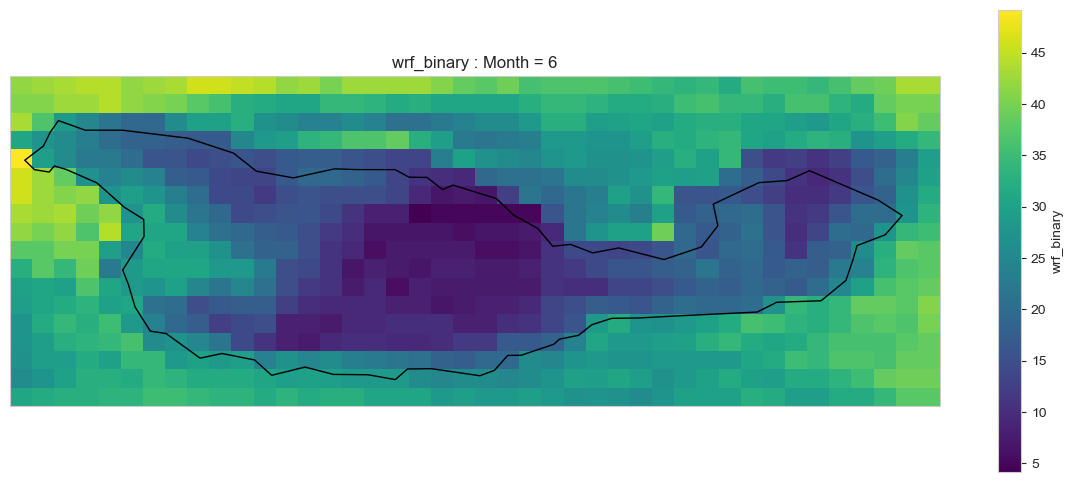

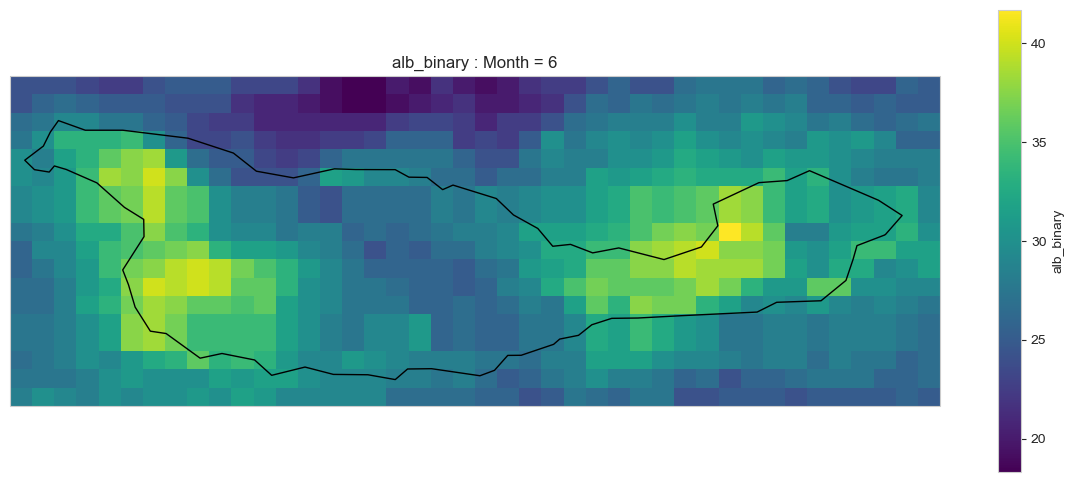

In [107]:
# Getting % of matching observations, aggregated by month
months = [6, 7]
months_ds = ds.groupby('time.month').sum('time')
months_count = ds.groupby('time.month').count('time')
months_ds = (months_ds / months_count) * 100

def plot_monthly(months_ds, month, var, calc_perc=False):
    perc_match = round(float(months_ds[var].sel(month=month).mean()),2)

    fig, ax = plt.subplots(figsize=(15, 12), subplot_kw={'projection': ccrs.PlateCarree()})
    months_ds[var].sel(month=month).plot(ax=ax, cbar_kwargs={"shrink": 0.5})
    if calc_perc:
        ax.set(title=f'{var} : Month = {month}\n{perc_match}% Match')
    else:
        ax.set(title=f'{var} : Month = {month}')
    ax.coastlines()
    plt.show()

plot_monthly(months_ds, 6, 'match', calc_perc=True)
plot_monthly(months_ds, 6, 'wrf_binary')
plot_monthly(months_ds, 6, 'alb_binary')